Shape of Dataset: (15, 12)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

First 5 Rows
  show_id     type            title                 director  \
0      s1    Movie       Red Notice  Rawson Marshall Thurber   
1      s2  TV Show  Stranger Things      The Duffer Brothers   
2      s3    Movie       Extraction             Sam Hargrave   
3      s4    Movie     The Irishman          Martin Scorsese   
4      s5  TV Show      Money Heist                Alex Pina   

                 cast        country date_added  release_year rating  \
0      Dwayne Johnson  United States 2021-11-12          2021  PG-13

/tmp/ipykernel_1575/3961443562.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


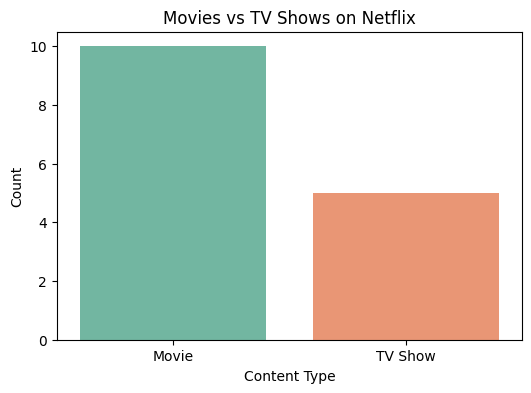

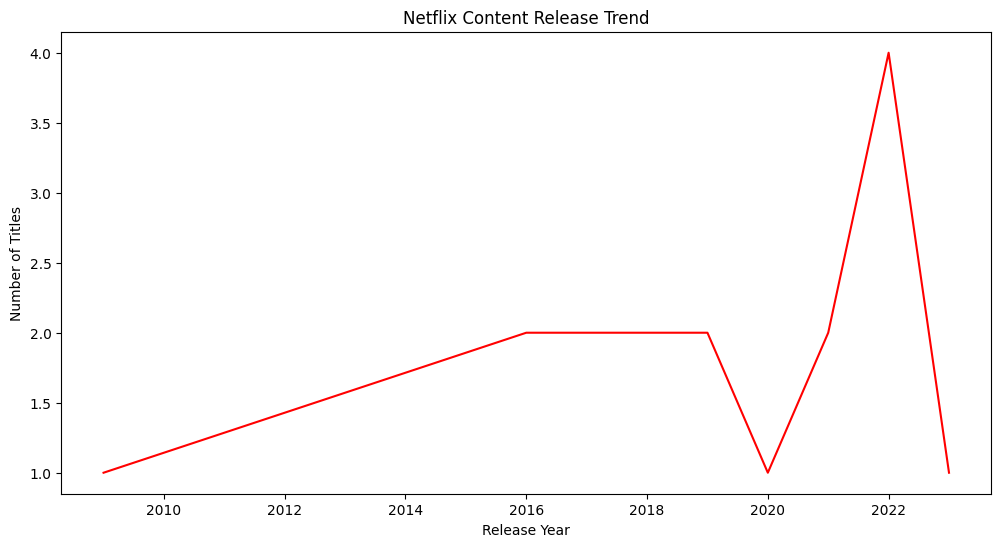

/tmp/ipykernel_1575/3961443562.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


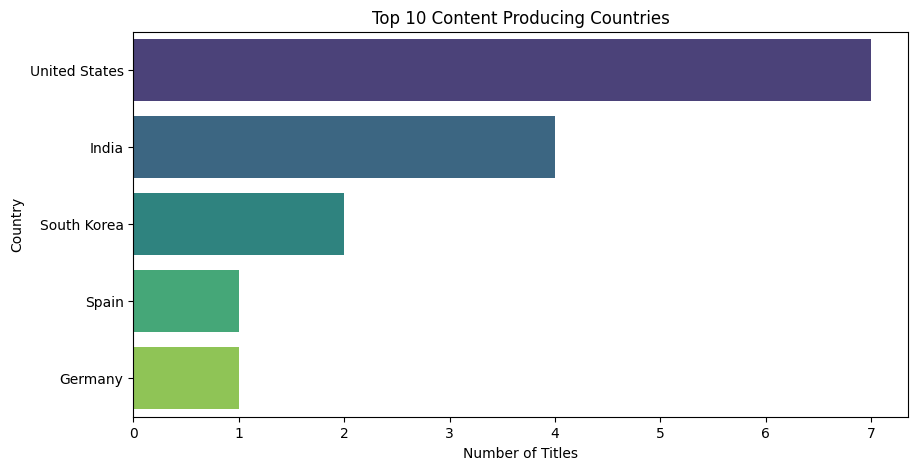

/tmp/ipykernel_1575/3961443562.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


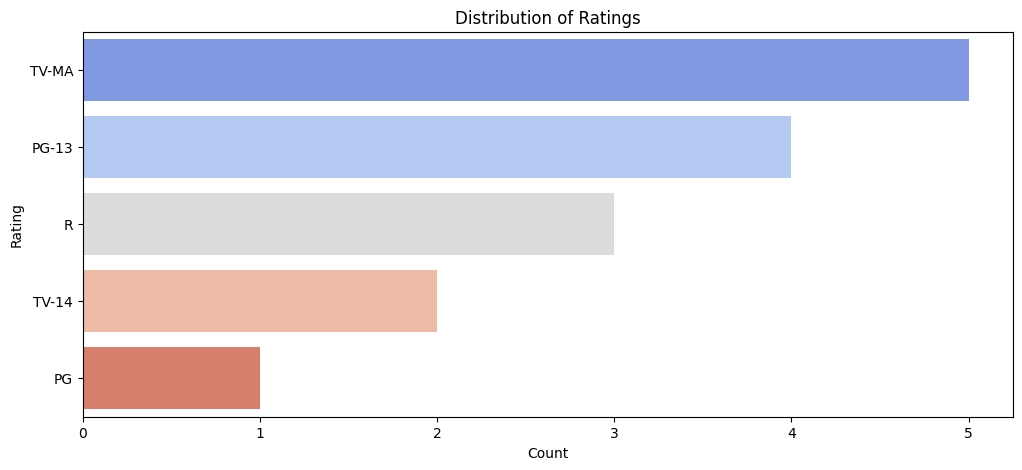

/tmp/ipykernel_1575/3961443562.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


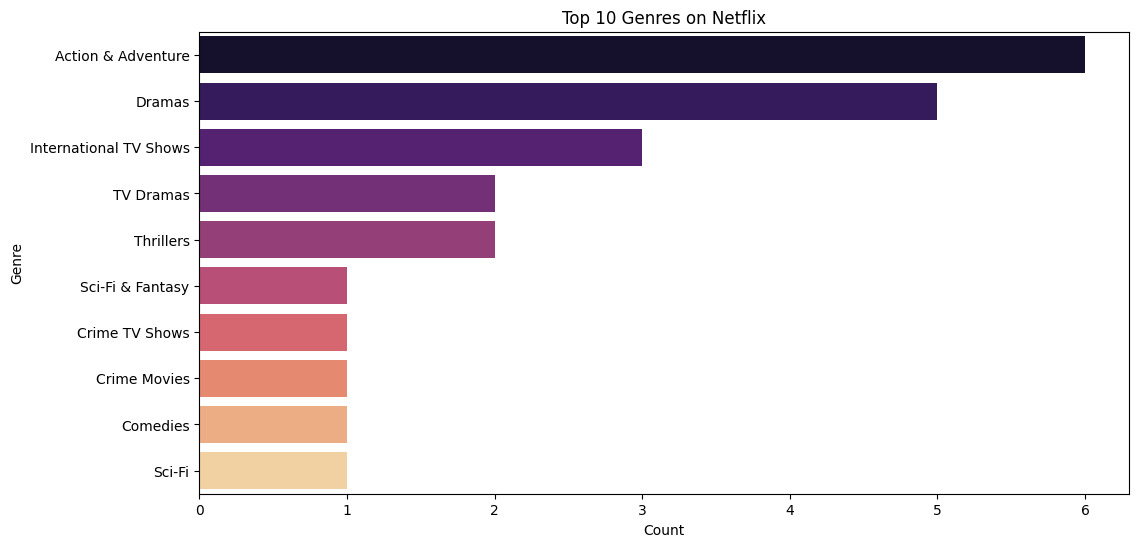


Content Count By Year:
release_year
2019    2
2020    1
2021    2
2022    4
2023    1
Name: show_id, dtype: int64

Summary Statistics:
       show_id   type       title                 director        cast  \
count       15     15          15                       15          15   
unique      15      2          15                       15          14   
top         s1  Movie  Red Notice  Rawson Marshall Thurber  Aamir Khan   
freq         1     10           1                        1           2   
mean       NaN    NaN         NaN                      NaN         NaN   
min        NaN    NaN         NaN                      NaN         NaN   
25%        NaN    NaN         NaN                      NaN         NaN   
50%        NaN    NaN         NaN                      NaN         NaN   
75%        NaN    NaN         NaN                      NaN         NaN   
max        NaN    NaN         NaN                      NaN         NaN   
std        NaN    NaN         NaN                 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ntflx.csv")
print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = pd.to_datetime(df['date_added'])
print("\nFirst 5 Rows")
print(df.head())

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()
plt.figure(figsize=(12,6))

release_year = df['release_year'].value_counts().sort_index()
sns.lineplot(
    x=release_year.index,
    y=release_year.values,
    color='red'
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

country_data = df['country'].dropna().str.split(', ')
country_list = []
for item in country_data:
    country_list.extend(item)
country_series = pd.Series(country_list)
top_countries = country_series.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis'
)

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index,
    palette='coolwarm'
)

plt.title("Distribution of Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

genre_data = df['listed_in'].str.split(', ')
genre_list = []
for item in genre_data:
    genre_list.extend(item)
genre_series = pd.Series(genre_list)
top_genres = genre_series.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='magma'
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()
content_by_year = df.groupby('release_year')['show_id'].count()

print("\nContent Count By Year:")
print(content_by_year.tail())
print("\nSummary Statistics:")
print(df.describe(include='all'))
print("\nKEY INSIGHTS")
print("1. Netflix has more Movies than TV Shows.")
print("2. Content production increased rapidly after 2015.")
print("3. United States produces the highest Netflix content.")
print("4. TV-MA is one of the most common ratings.")
print("5. Drama and International Movies dominate genres.")